# LSTM- Model

## 1. Importing the libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

## 2. loading the data

In [23]:
#taking the input to ask the user to choose the company
name = input("Enter the name of the company").upper()
name

#taking the dataset 
df = pd.read_csv(f"../data-companywise/processed_data/{name}.csv")
df

Enter the name of the company shl


,date,open,high,low,close,price_change_pct,volume,turnover,year,eps,pe-ratio,roe,dividend
0,2022-01-02,210.5,210.5,205.8,208.0,-0.48,18999.0,3932807.0,2022,1.95,98.4,11.5,26.3
1,2022-01-03,209.0,213.0,208.0,211.0,1.44,17758.0,3749380.5,2022,1.95,98.4,11.5,26.3
2,2022-01-04,210.0,215.3,208.0,214.0,1.42,36481.0,7770474.5,2022,1.95,98.4,11.5,26.3
3,2022-01-05,214.0,217.0,208.8,210.3,-1.73,17351.0,3707132.8,2022,1.95,98.4,11.5,26.3
4,2022-01-06,211.0,220.0,208.0,217.0,3.19,29617.0,6320346.1,2022,1.95,98.4,11.5,26.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,2025-12-23,478.0,485.0,471.0,479.5,0.19,15466.0,7425662.4,2025,6.56,81.7,25.6,31.6
924,2025-12-24,479.5,486.0,475.0,480.5,0.21,11182.0,5374158.5,2025,6.56,81.7,25.6,31.6
925,2025-12-28,470.9,490.1,470.9,488.5,1.66,12144.0,5920904.6,2025,6.56,81.7,25.6,31.6
926,2025-12-29,485.0,493.0,480.0,488.1,-0.08,29177.0,14280950.5,2025,6.56,81.7,25.6,31.6


## 3. Dropping the unnecessary columns

In [24]:
#eps, pe, roe and dividend, turnover, year
df.drop(columns = ['eps','roe','dividend','pe-ratio', 'year','turnover'],inplace = True)
df

,date,open,high,low,close,price_change_pct,volume
0,2022-01-02,210.5,210.5,205.8,208.0,-0.48,18999.0
1,2022-01-03,209.0,213.0,208.0,211.0,1.44,17758.0
2,2022-01-04,210.0,215.3,208.0,214.0,1.42,36481.0
3,2022-01-05,214.0,217.0,208.8,210.3,-1.73,17351.0
4,2022-01-06,211.0,220.0,208.0,217.0,3.19,29617.0
...,...,...,...,...,...,...,...
923,2025-12-23,478.0,485.0,471.0,479.5,0.19,15466.0
924,2025-12-24,479.5,486.0,475.0,480.5,0.21,11182.0
925,2025-12-28,470.9,490.1,470.9,488.5,1.66,12144.0
926,2025-12-29,485.0,493.0,480.0,488.1,-0.08,29177.0


In [25]:
# reviewing the data
print(df.head())
print(df.shape)
print(df.dtypes)


         date   open   high    low  close  price_change_pct   volume
0  2022-01-02  210.5  210.5  205.8  208.0             -0.48  18999.0
1  2022-01-03  209.0  213.0  208.0  211.0              1.44  17758.0
2  2022-01-04  210.0  215.3  208.0  214.0              1.42  36481.0
3  2022-01-05  214.0  217.0  208.8  210.3             -1.73  17351.0
4  2022-01-06  211.0  220.0  208.0  217.0              3.19  29617.0
(928, 7)
date                 object
open                float64
high                float64
low                 float64
close               float64
price_change_pct    float64
volume              float64
dtype: object


## 4. Cleaning and preparing the data

In [26]:
#Converting the date to datetime and sort
df['date'] = pd.to_datetime(df['date'])
df =  df.sort_values('date').reset_index(drop = True)
df

,date,open,high,low,close,price_change_pct,volume
0,2022-01-02,210.5,210.5,205.8,208.0,-0.48,18999.0
1,2022-01-03,209.0,213.0,208.0,211.0,1.44,17758.0
2,2022-01-04,210.0,215.3,208.0,214.0,1.42,36481.0
3,2022-01-05,214.0,217.0,208.8,210.3,-1.73,17351.0
4,2022-01-06,211.0,220.0,208.0,217.0,3.19,29617.0
...,...,...,...,...,...,...,...
923,2025-12-23,478.0,485.0,471.0,479.5,0.19,15466.0
924,2025-12-24,479.5,486.0,475.0,480.5,0.21,11182.0
925,2025-12-28,470.9,490.1,470.9,488.5,1.66,12144.0
926,2025-12-29,485.0,493.0,480.0,488.1,-0.08,29177.0


In [27]:
#chceking for the null values
df.isnull().sum()

date                0
open                0
high                0
low                 0
close               0
price_change_pct    0
volume              0
dtype: int64

In [28]:
#total traded days
print(f"total trading days :{len(df)}")

total trading days :928


In [29]:
# 3. Set as index
df.set_index('date', inplace=True)

In [30]:
df

,open,high,low,close,price_change_pct,volume
date,,,,,,
2022-01-02,210.5,210.5,205.8,208.0,-0.48,18999.0
2022-01-03,209.0,213.0,208.0,211.0,1.44,17758.0
2022-01-04,210.0,215.3,208.0,214.0,1.42,36481.0
2022-01-05,214.0,217.0,208.8,210.3,-1.73,17351.0
2022-01-06,211.0,220.0,208.0,217.0,3.19,29617.0
...,...,...,...,...,...,...
2025-12-23,478.0,485.0,471.0,479.5,0.19,15466.0
2025-12-24,479.5,486.0,475.0,480.5,0.21,11182.0
2025-12-28,470.9,490.1,470.9,488.5,1.66,12144.0


## 5. Visualizing the all features

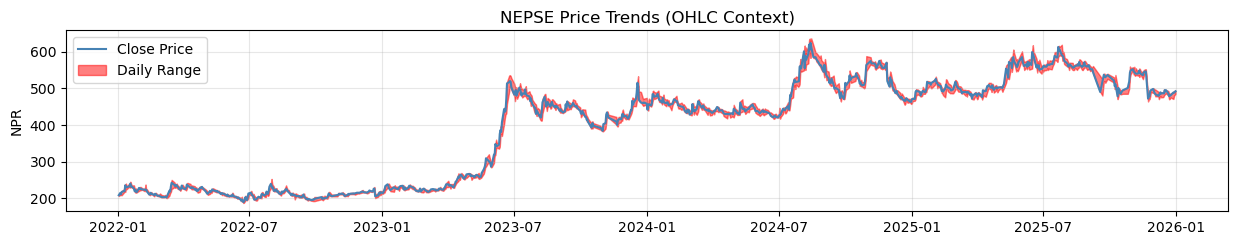

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

#plotting the price trends
plt.figure(figsize = (15,8))
plt.subplot(3,1,1)
plt.plot(df.index, df['close'], label='Close Price', color='steelblue', linewidth=1.5)
plt.fill_between(df.index, df['low'], df['high'], alpha=0.5, color='red', label='Daily Range')
plt.title('NEPSE Price Trends (OHLC Context)')
plt.ylabel('NPR')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

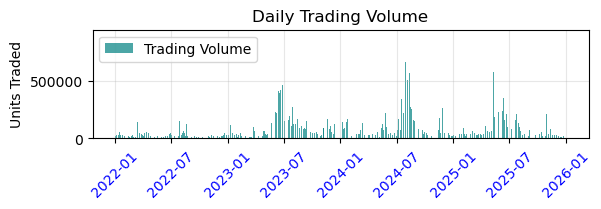

In [50]:
# 2. Plotting Volume (Market Activity)
plt.subplot(3, 1, 2)
plt.bar(df.index, df['volume'], color='teal', alpha=0.7, label='Trading Volume')
plt.title('Daily Trading Volume')
plt.ylabel('Units Traded')
plt.legend(loc='upper left')
plt.xticks(rotation=45, color = 'blue')
plt.grid(True, alpha=0.3)
plt.show()

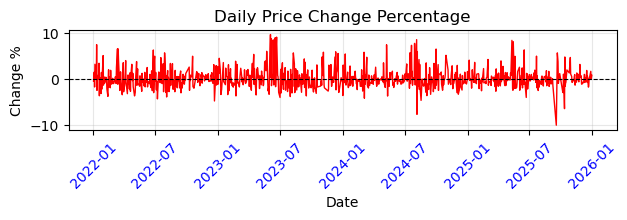

In [58]:
# 3. Plotting Price Change % (Momentum)
plt.subplot(3, 1, 3)
plt.plot(df.index, df['price_change_pct'], color='red', linewidth=1)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Zero line
plt.title('Daily Price Change Percentage')
plt.xlabel('Date')
plt.ylabel('Change %')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, color = 'blue')
plt.tight_layout()
plt.show()

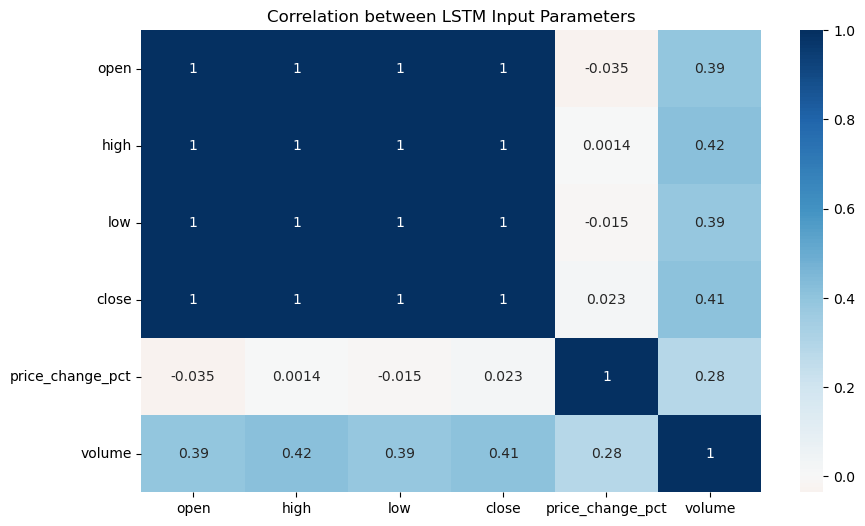

In [65]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='RdBu', center=0) #rdbu re
plt.title('Correlation between LSTM Input Parameters')
plt.show()

## 6- Scaling the data

In [66]:
#using the min-max scaling .